# ARGUS-FEDER on JupyterHub — Pelican Data Access, Metadata, and PTDATA Basics

This notebook demonstrates ARGUS answering natural-language questions about
DIII-D data through several different access paths: semantic concept →
MDSplus signal resolution, the shot-metadata database, PTDATA (a separate
raw-digitizer data source), and IMAS (the device-neutral naming standard).
Each `%%ask` cell sends a plain-English request; ARGUS consults the DIII-D
skills, writes and runs the code, and reports back.

JupyterHub counterpart of **`argus_feder_pelican_database_ptdata_colab.ipynb`**.
Every `%%ask` request is identical to the Colab version, so the two can be
compared directly.

**Prerequisites.** The image already has TokSearch, ARGUS and the DIII-D skills
installed -- there is no install step and no `pip`/`conda` cell in this notebook.
You need two things in place:

1. **LLM key** -- `NRP_API_KEY` in the environment, or a `.env` holding it in the
   working directory. ARGUS re-reads that `.env` on every `%%ask`.
2. **Pelican token** -- save it to
   `~/work/_User-Persistent-Storage_CephBlock_/.fdp/token` (survives pod restarts;
   `~/.fdp/token` also works but is wiped when the pod recycles). If the kernel was
   already running when you added it, call `reload_pelican()` -- no restart needed.

Then run the `%reset` cell below and any `%%ask` cell, in any order.


In [ ]:
%reset

## 1. Semantic concept → signal mapping

**Purpose:** can ARGUS resolve a physics CONCEPT to the right MDSplus signal with
no symbol name given? Each request below deliberately omits the `\name`.
then short per-item lines, e.g.:

### Plasma current

I'll plan this task, then consult the shot-fetcher skill before writing any code.



The skill is clear: use `fdp run python script.py` with `MdsSignal(r"\ipmhd", "efit01")`. Let me check the working directory, then write the fetch-and-plot script.



Writing the fetch-and-plot script following the skill's verified pattern.



Running the script with the required `fdp run` wrapper.



Fetch succeeded on the first run: 311 samples, min 2.92e5 A, max 1.19e6 A. There's a harmless `SyntaxWarning` from the non-raw docstring (the skill explicitly warns about this) — fixing it and re-running for a clean result.



Clean run confirmed. Verifying the output files exist.



Fetched `\ipmhd` from the `efit01` MDSplus tree for shot 165340 via TokSearch (run under `fdp run` per the skill's execution rule).

**Results**

- **Samples** : 311
- **Time base** : 100.0 – 6360.0 ms
- **Min** : 2.9202e+05 A (0.292 MA)
- **Max** : 1.1878e+06 A (1.188 MA)
- **Units** : Amperes (A) — raw `\ipmhd` from efit01 is in A; the plot is shown in MA

The trace shows the typical discharge shape: current ramp-up from ~0.29 MA at 100 ms, a flat-top plateau near ~1.19 MA, and ramp-down to the end of the record at 6360 ms.


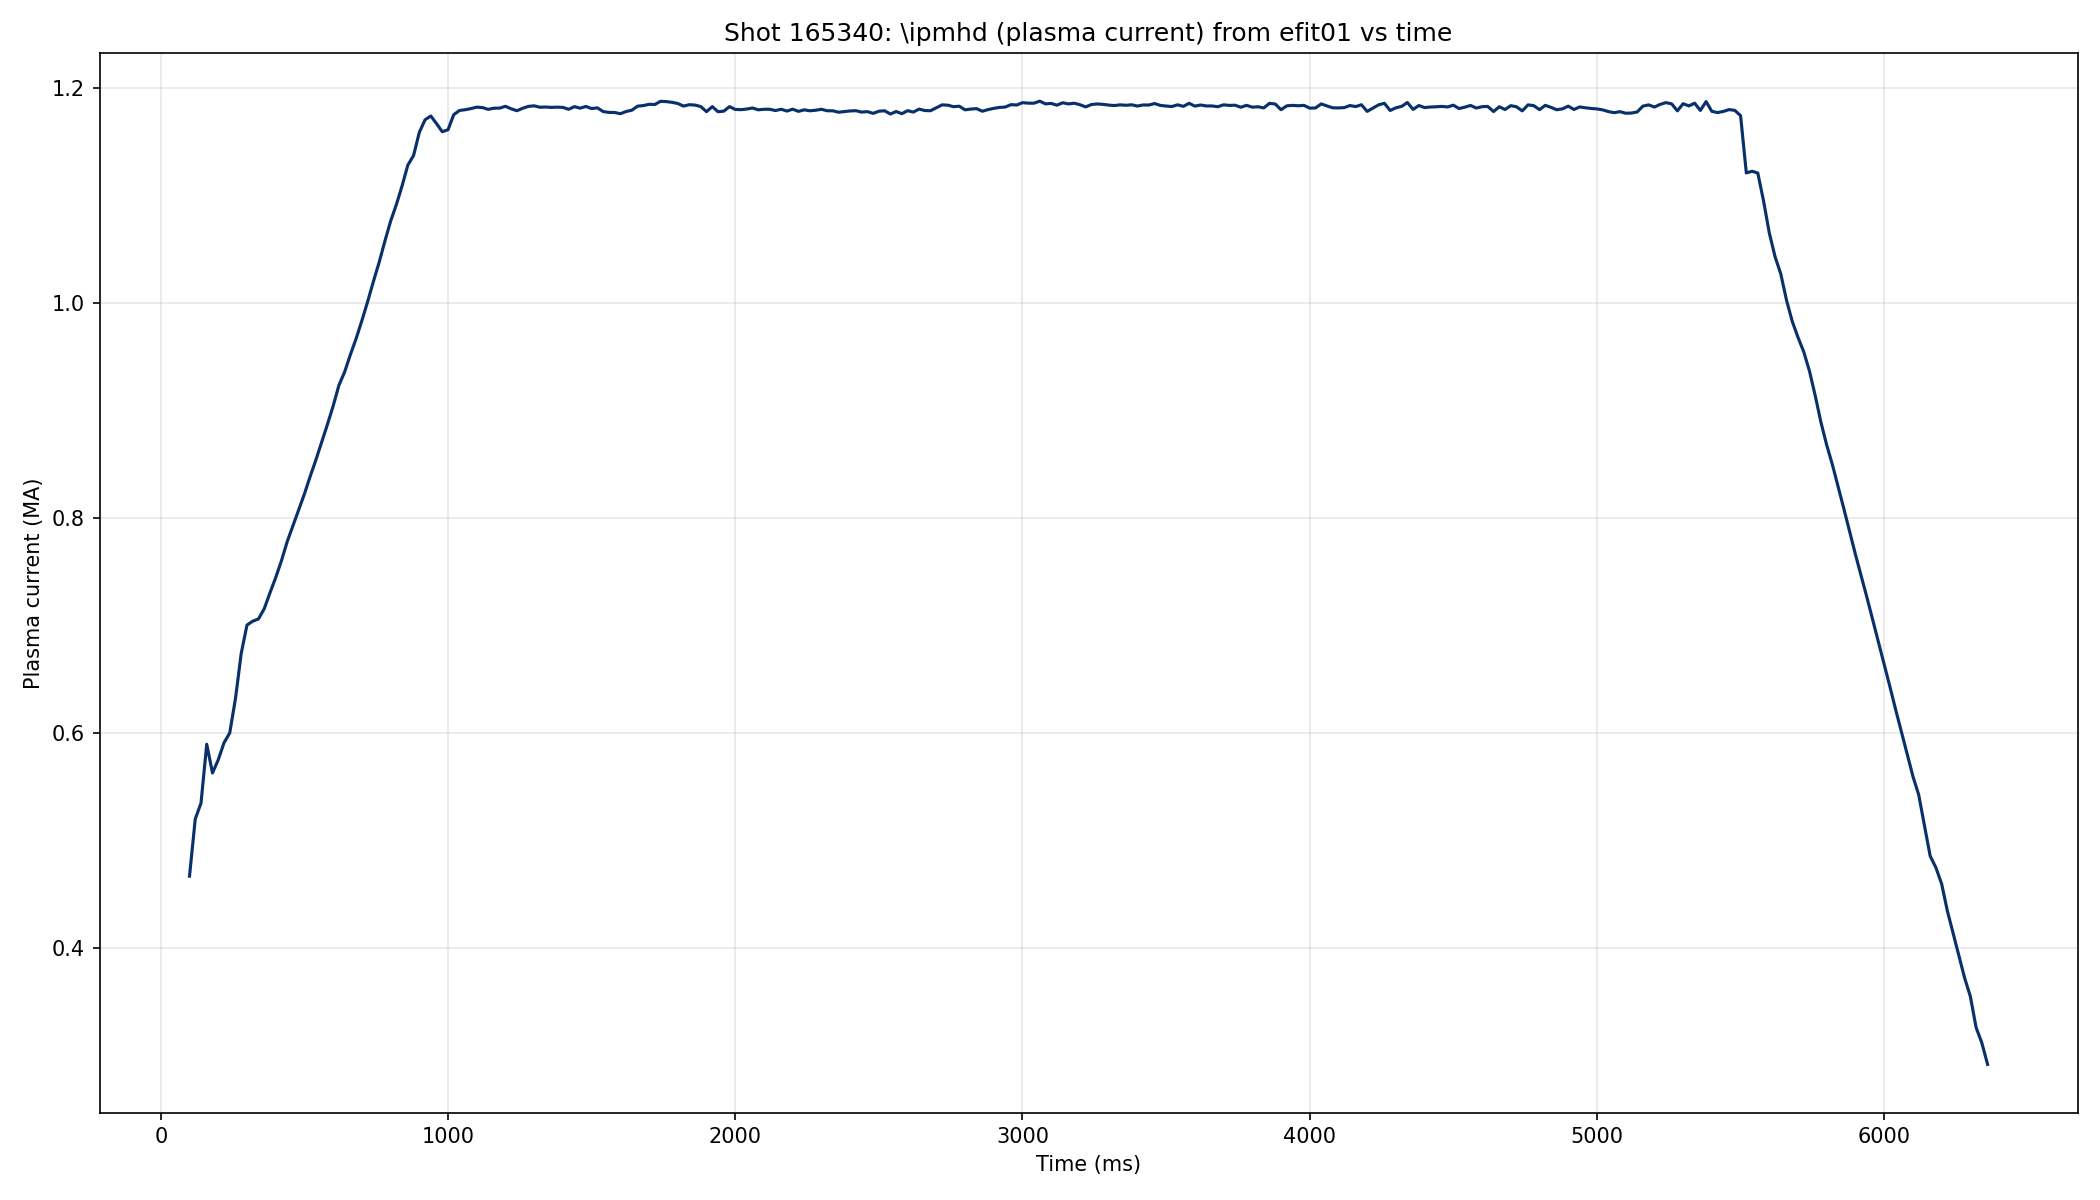

The raw time–current data is also saved as `ipmhd_165340.csv` (columns: `time_ms, ipmhd_A`) alongside the script `fetch_ipmhd_165340.py` in the working directory.

In [2]:
%%ask
Fetch \ipmhd from efit01 for shot 165340 and plot it versus time, and
report the number of samples and the min/max with units.

### Elongation
**Ask:** "plasma elongation" (no `\kappa` given) → should resolve to `efit01/\kappa`.

I'll consult the d3d-shot-fetcher skill for the correct way to fetch elongation from the equilibrium reconstruction.



The skill confirms `\kappa` in `efit01` is the plasma elongation, and this is a time-series request (plot vs time), so a raw fetch is appropriate. Let me check the working directory and the previous fetch script to reuse the verified pattern.



The previous script's pattern is verified. Writing the analogous script for `\kappa` (elongation) from `efit01`.



Running the fetch under `fdp run` as required by the skill.



Fetched `\kappa` (plasma elongation) from the `efit01` MHD equilibrium reconstruction for shot 165340 via TokSearch (run under `fdp run`).

**Results**

- **Samples** : 311
- **Time base** : 100.0 – 6360.0 ms
- **Min** : 1.4361
- **Max** : 1.9452
- **Units** : dimensionless (elongation is a ratio; the efit01 units field is empty)

The trace shows the expected evolution: elongation rises from ~1.44 during the current ramp-up, peaks near ~1.95 during the flat-top, and decreases during ramp-down.


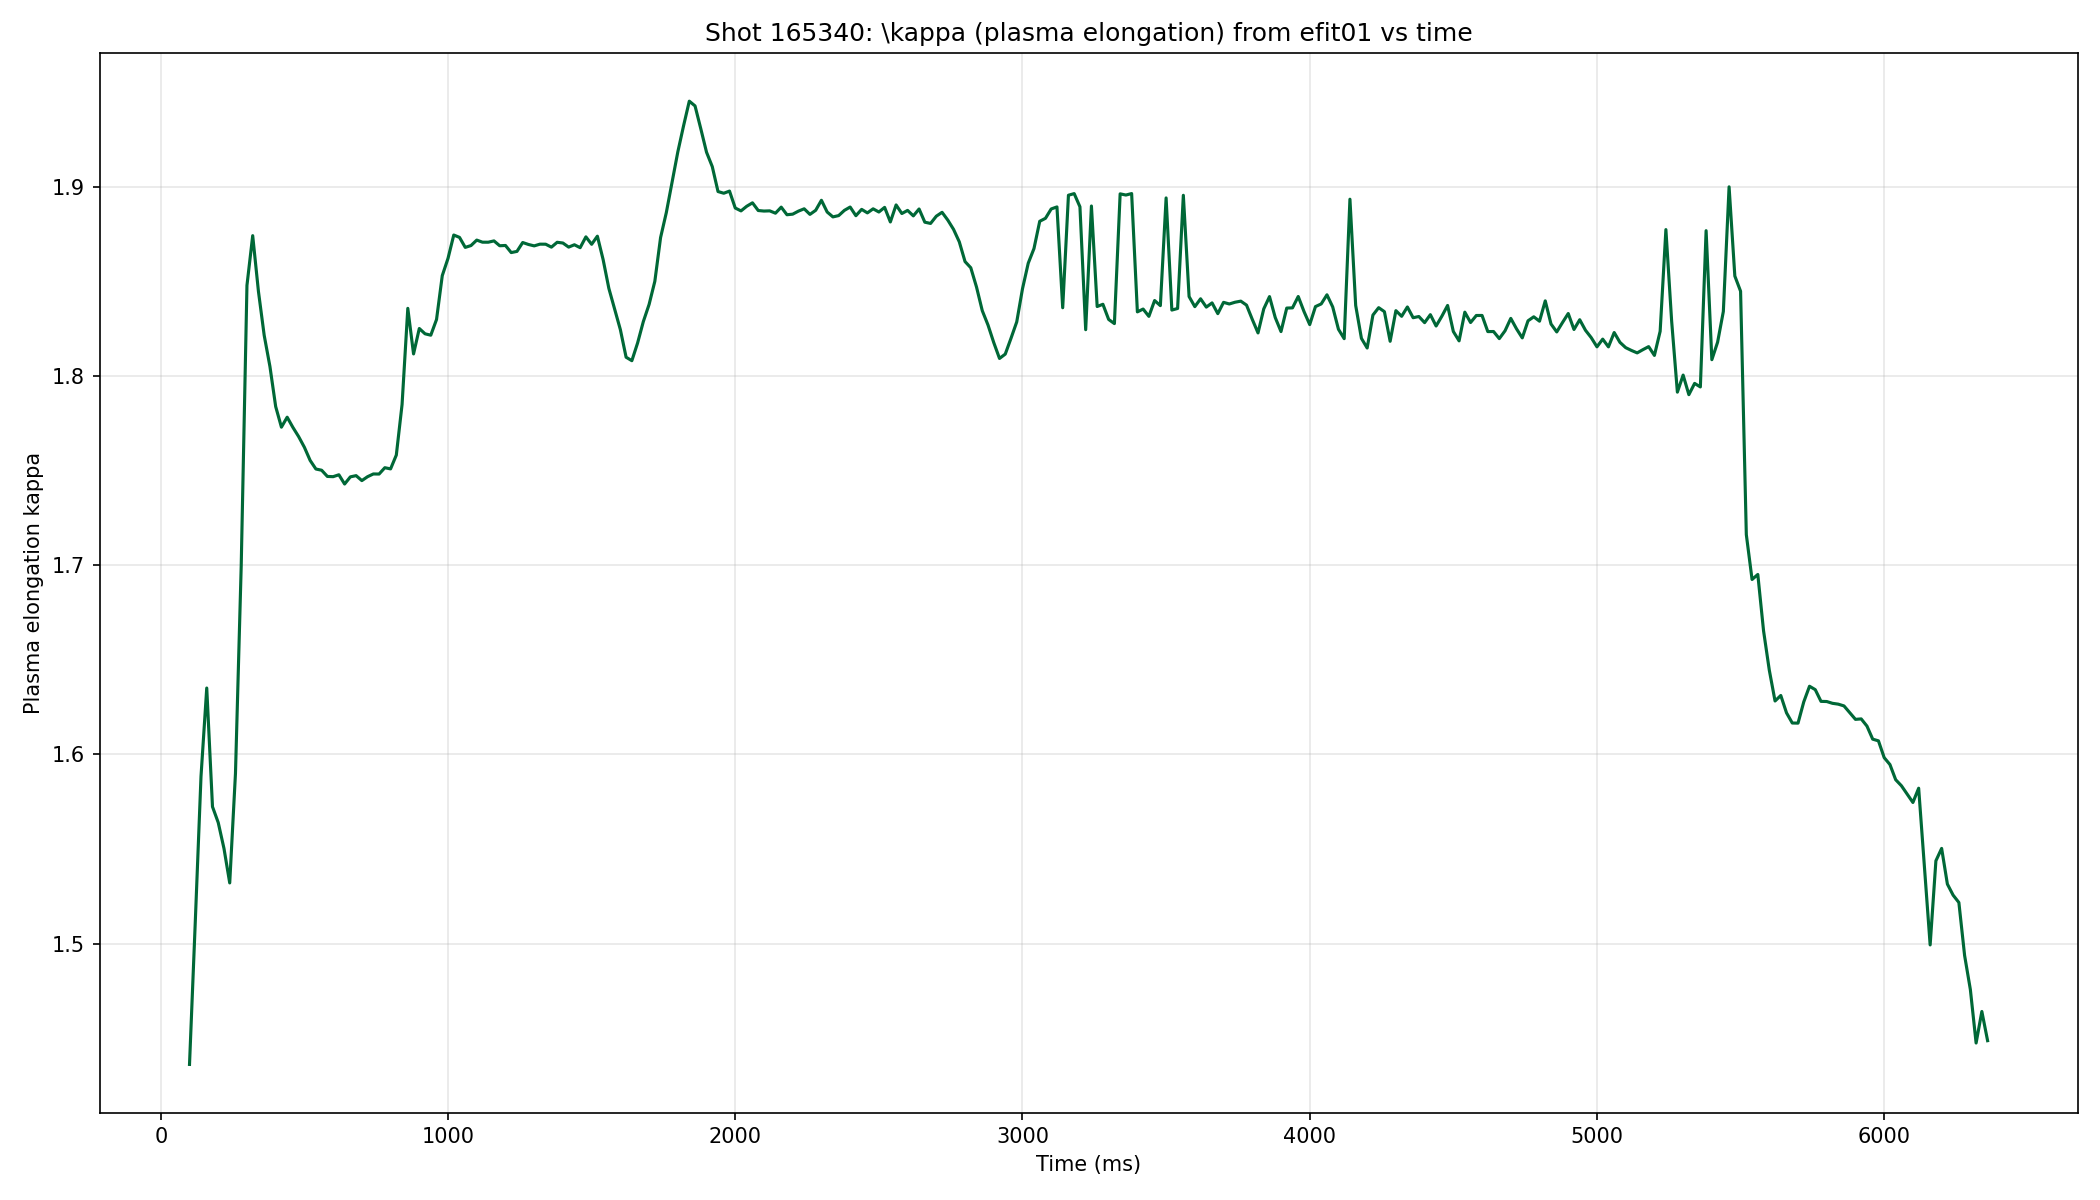

The raw time–elongation data is saved as `kappa_165340.csv` (columns: `time_ms, kappa`), with the script `fetch_kappa_165340.py` in the working directory.

In [3]:
%%ask
For DIII-D shot 165340, fetch the plasma elongation from the MHD equilibrium
reconstruction, plot it versus time, and report its min and max.

### Safety factor at 95% flux surface
**Ask:** no "MHD equilibrium" qualifier this time — the harder disambiguation case.  
**Expected:** resolves to `efit01/\q95` anyway.

I'll plan this task, then consult the shot-fetcher skill and reuse the working pattern from the previous fetches.



Reading the existing kappa fetch script to reuse the verified pattern.



Writing the q95 fetch script, modeled on the verified kappa pattern.



Running the fetch under `fdp run` as required for DIII-D data access.



Fetched `\q95` (safety factor at the 95% flux surface) from the `efit01` MHD equilibrium reconstruction for shot 165340 via TokSearch (run under `fdp run`).

**Results**

- **Samples** : 311
- **Time base** : 100.0 – 6360.0 ms
- **Min** : 4.5581
- **Max** : 9.4376
- **Units** : dimensionless (safety factor is a ratio; the efit01 units field is empty)

The trace shows the expected evolution: q95 starts high (~9.4) during the early current ramp-up, decreases as the plasma current rises, reaches a minimum near ~4.6 during the flat-top, and rises again during ramp-down.


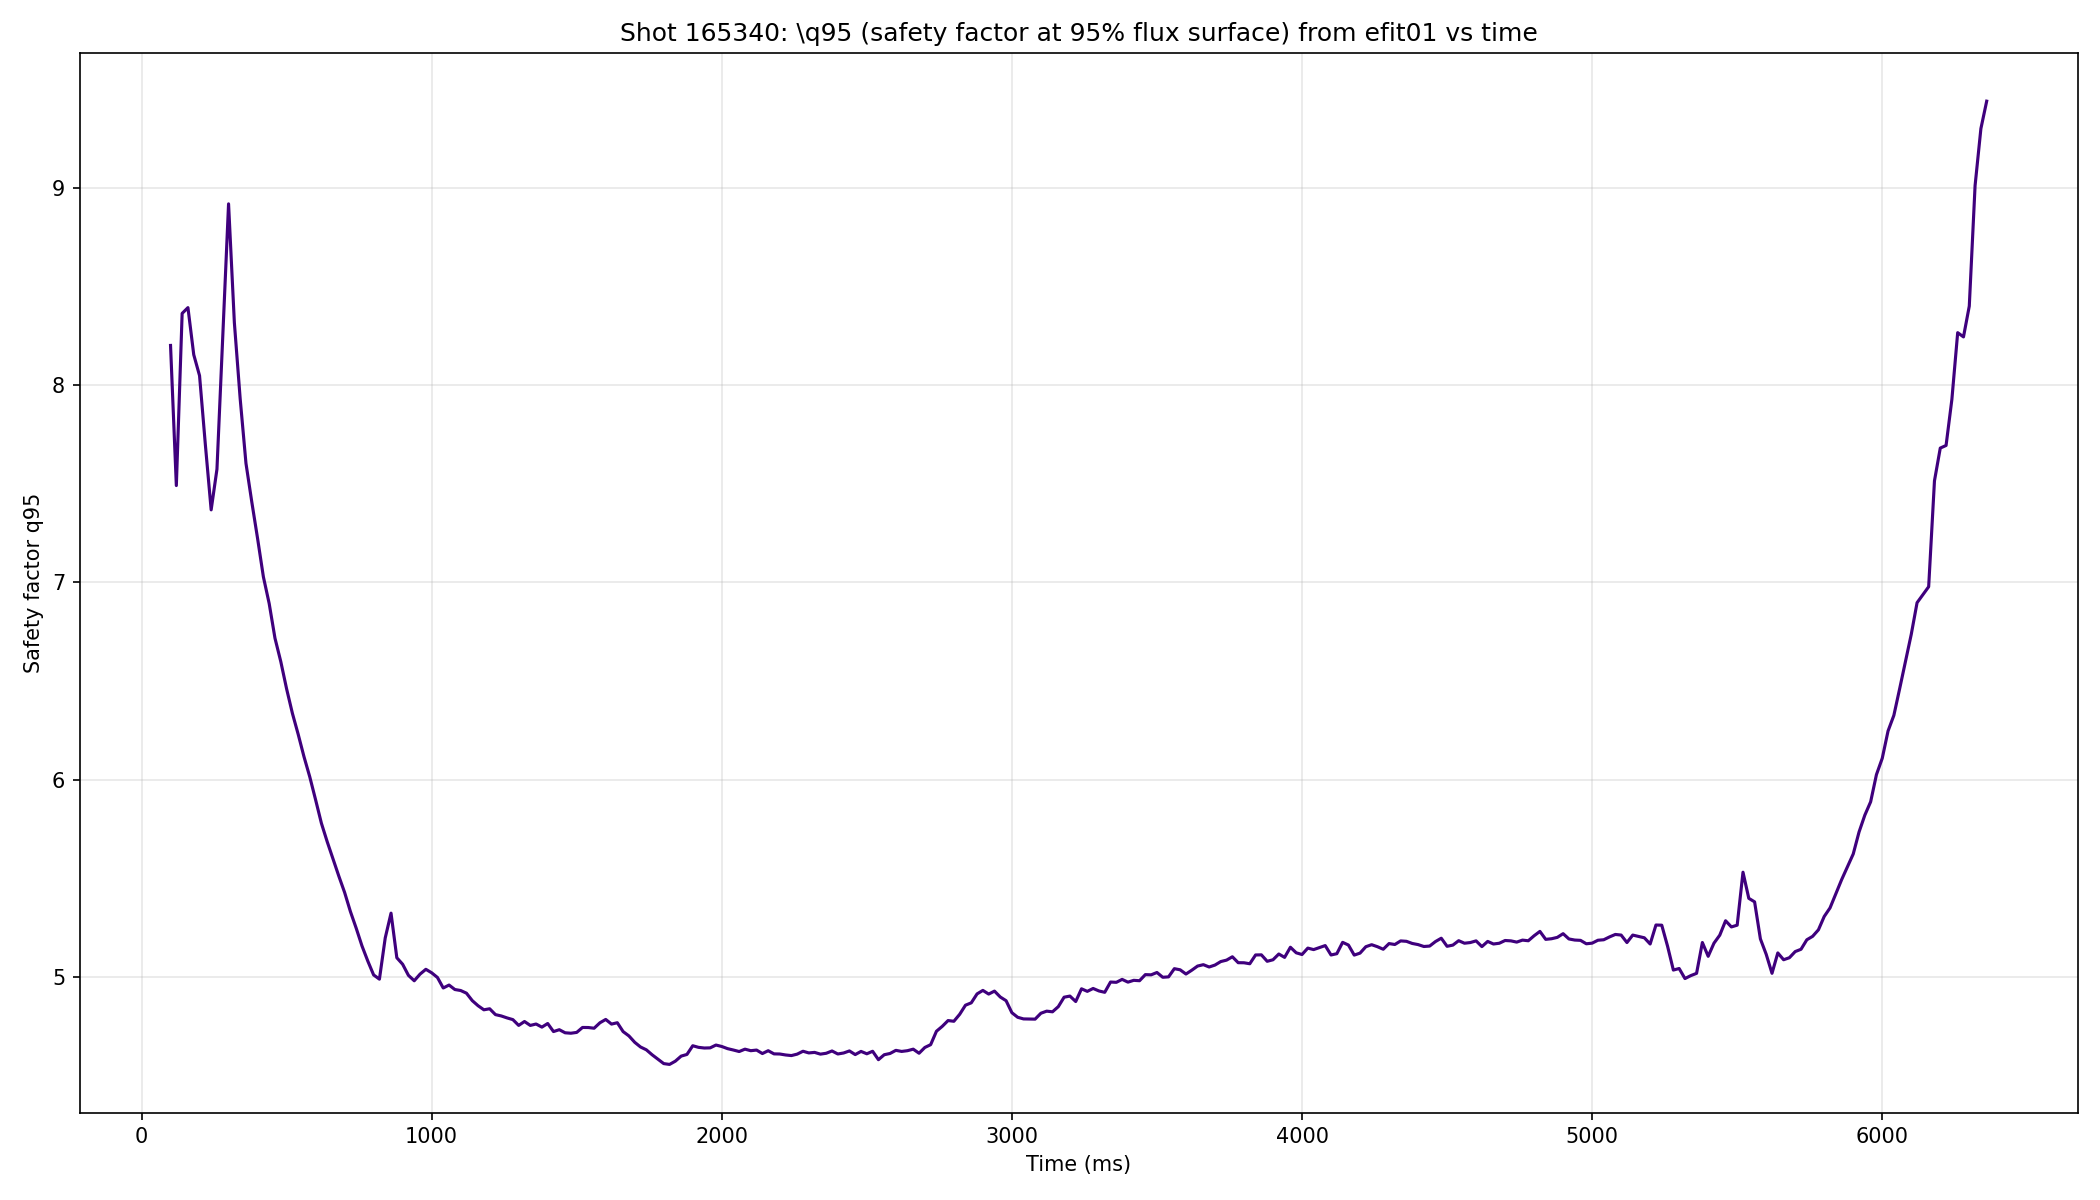

The raw time–q95 data is saved as `q95_165340.csv` (columns: `time_ms, q95`), with the script `fetch_q95_165340.py` in the working directory.

In [4]:
%%ask
For shot 165340, fetch the safety factor at the 95% flux surface,
plot it versus time, and report its range.

### Multi-shot overlay
**Purpose:** test the fetch-many-shots-and-compare pattern, not just concept mapping.

I'll plan this task, then consult the shot-fetcher skill and check the existing scripts from earlier fetches.



Reading the existing ipmhd fetch script to reuse the verified pattern.



The existing script uses the verified `pipe.fetch` + `compute_serial` pattern. I'll write a multi-shot version that overlays all three traces on one chart, using a single color with distinct line styles (per the color-by-class rule) and a legend.



Running the fetch under `fdp run` as required by the skill.



All three shots fetched cleanly. Updating the todo list and reporting.



Fetched `\ipmhd` (plasma current) from the `efit01` MHD equilibrium reconstruction for all three shots via TokSearch (run under `fdp run`).

**Peak current per shot**

| Shot | Samples | Time range (ms) | Peak current | Min current |
|---|---|---|---|---|
| 165340 | 311 | 100 – 6360 | 1.188 MA | 0.292 MA |
| 188702 | 314 | 100 – 6960 | 1.007 MA | 0.196 MA |
| 194181 | 212 | 220 – 4560 | 0.599 MA | 0.375 MA |

Raw `\ipmhd` is in Amperes (A); values above are converted to MA. The three discharges differ in both peak current and duration: 165340 is the highest-current shot (~1.19 MA), 188702 is intermediate (~1.01 MA), and 194181 is a lower-current, shorter discharge (~0.60 MA, ending at 4560 ms).


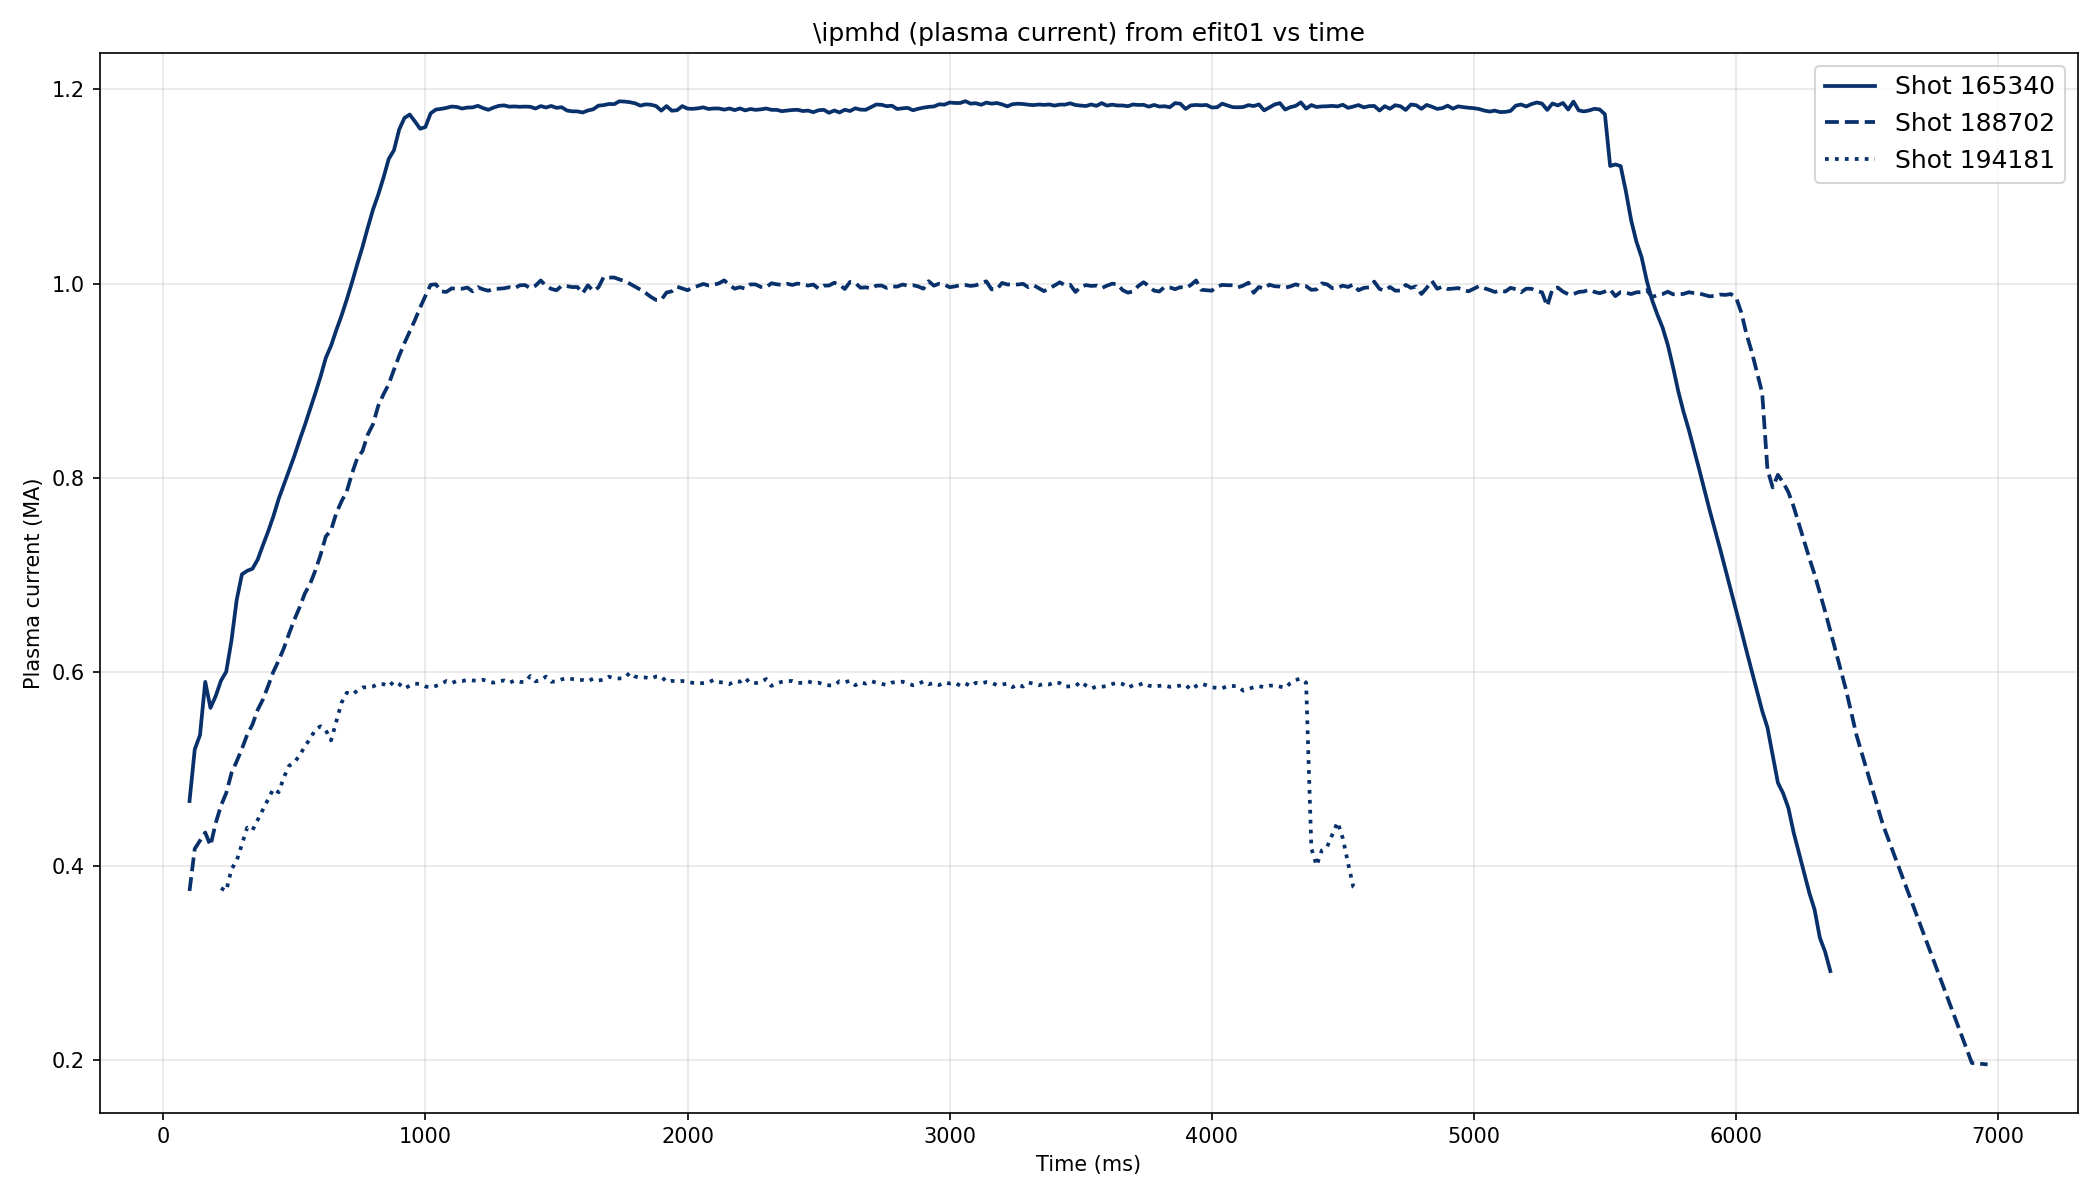

Per-shot raw data is saved as `ipmhd_165340.csv`, `ipmhd_188702.csv`, and `ipmhd_194181.csv` (columns: `time_ms, ipmhd_A`), with the script `fetch_ipmhd_overlay.py` in the working directory.

In [5]:
%%ask
For DIII-D shots 165340, 188702, and 194181, fetch the plasma current from the MHD
equilibrium reconstruction and overlay all three on a single chart. Report each
shot's peak current.

### Multi-shot shape comparison
**Purpose:** same multi-shot pattern, a dimensionless quantity (elongation) this time.

I'll plan this task, then consult the shot-fetcher skill before writing any code.



Skill read — I'll use the required `fetch_dataset` pattern with the `\psirz` anchor and run under `fdp run`. Writing the fetch-and-overlay script now.



Running the fetch under `fdp run` as required.



Fetched `\kappa` (plasma elongation) from the `efit01` MHD equilibrium reconstruction for all three shots via TokSearch (run under `fdp run`).

**Elongation range per shot**

| Shot | Samples | Time range (ms) | Min κ | Max κ |
|---|---|---|---|---|
| 165340 | 311 | 100 – 6360 | 1.4361 | 1.9452 |
| 188702 | 314 | 100 – 6960 | 1.3051 | 1.9077 |
| 194181 | 212 | 220 – 4560 | 1.1471 | 1.4860 |

Elongation is dimensionless. The overlay shows the shape evolution of each discharge: 165340 and 188702 both reach a strongly shaped flat-top (κ ≈ 1.9), while 194181 is a much rounder, lower-elongation discharge (κ peaks at only ~1.49) and is also the shortest of the three.


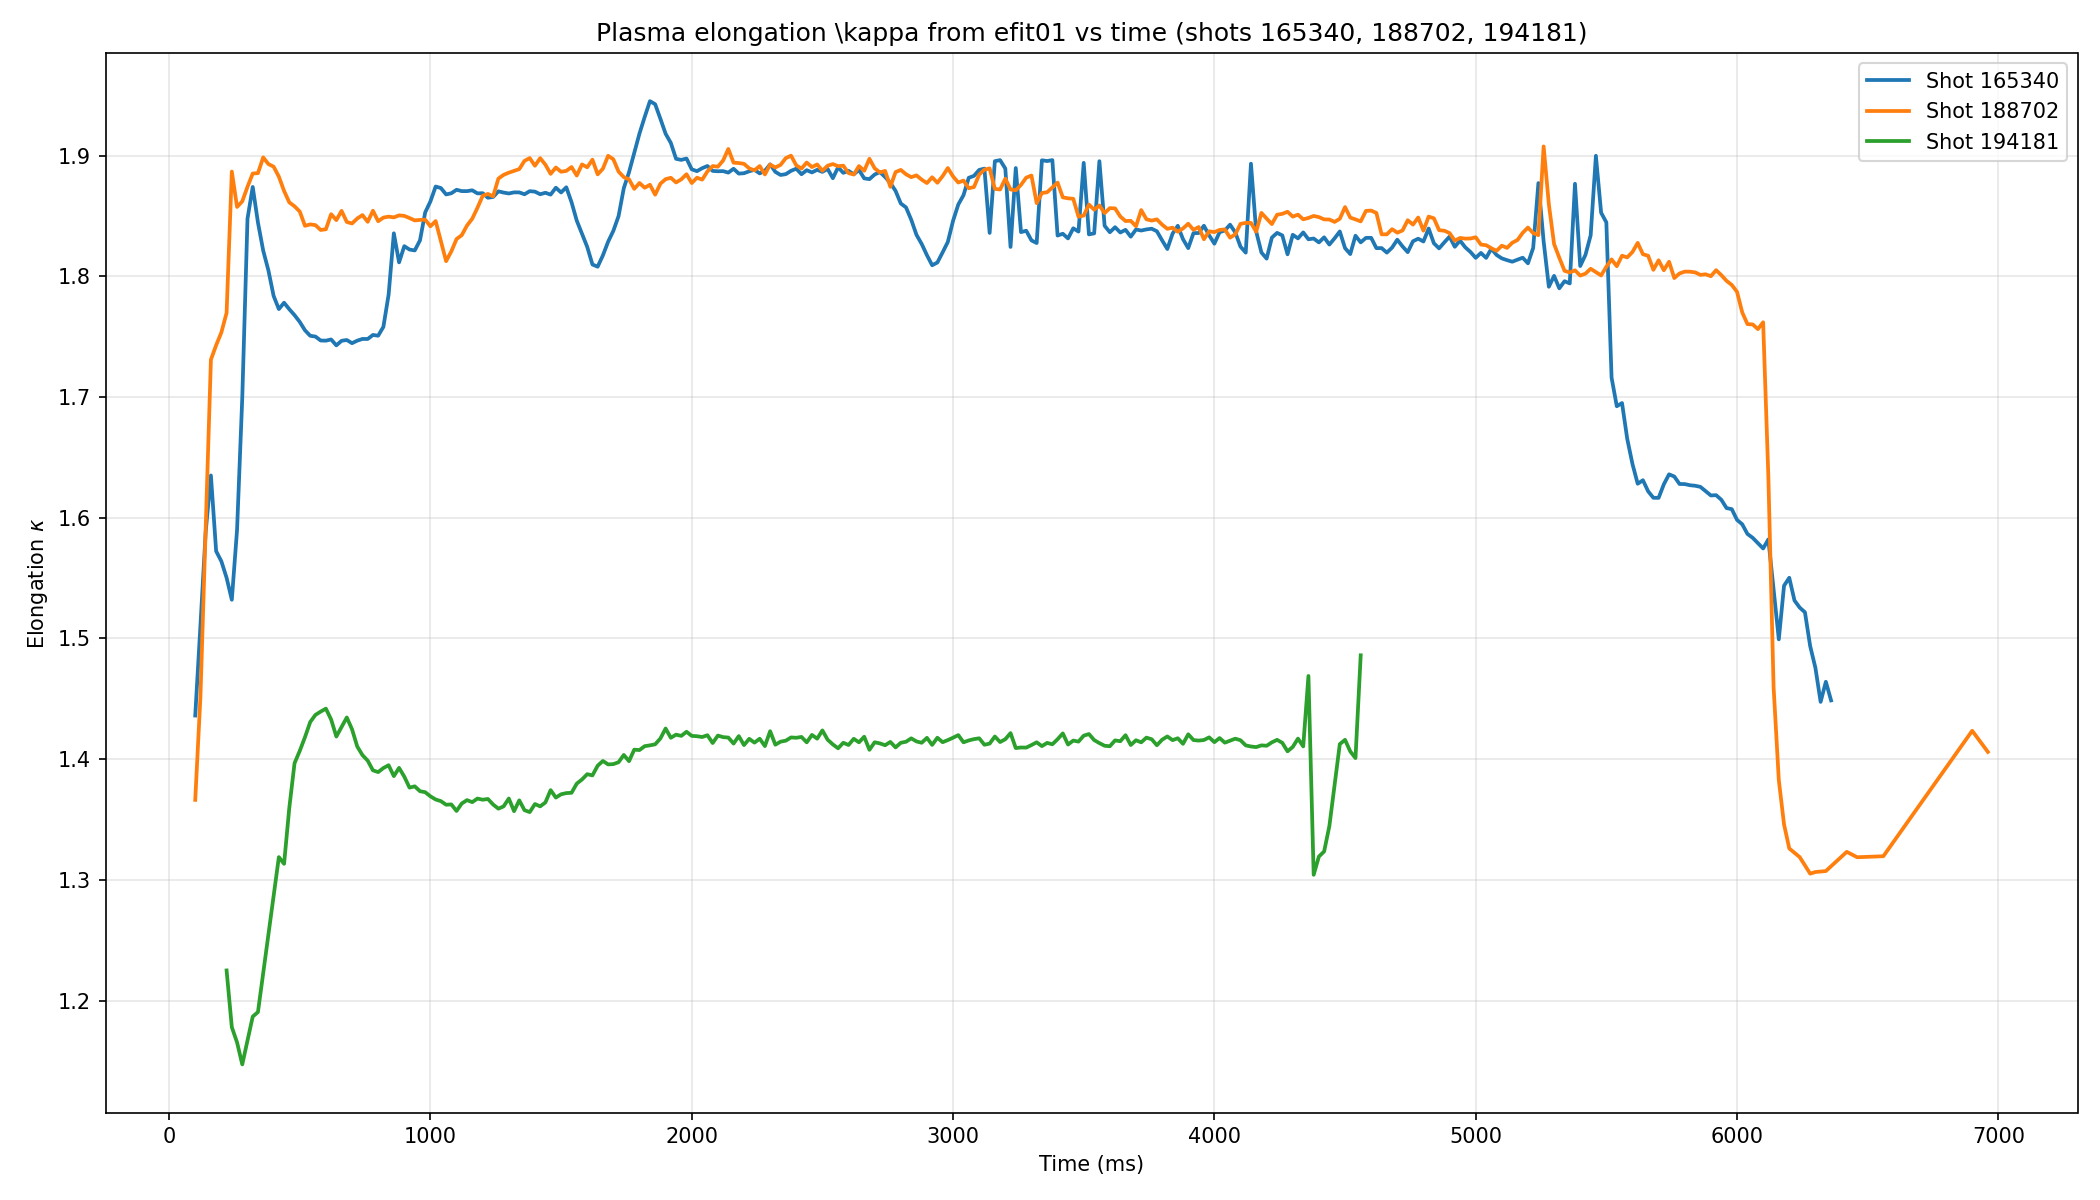

Per-shot raw data is saved as `kappa_165340.csv`, `kappa_188702.csv`, and `kappa_194181.csv` (columns: `time_ms, kappa`), with the script `fetch_kappa_overlay.py` in the working directory.

In [6]:
%%ask
Compare the plasma shape across DIII-D shots 165340, 188702, and 194181 by fetching
the elongation from the MHD equilibrium reconstruction and overlaying it versus time
on one chart with a legend.

## 2. Metadata from Database

The shot metadata is served by the FEDER lakehouse over HTTP -- there is nothing to download and nothing to place in a folder. It needs outbound network and a valid FDP token (`~/.fdp/token`, or the copy under `~/work/_User-Persistent-Storage_CephBlock_/.fdp/token`) -- the same token DIII-D data access already uses.

In [7]:
%%ask
How many DIII-D plasma shots were there between 190000 and 195000?

This is a shot-catalog query, so I'll consult the d3d-relational-db skill first.



The skill documents `plasma_shots_in_range` for exactly this query. I'll run it to get the actual count rather than quoting the example.



Running the count query against the shot records.



**There were 3,507 DIII-D plasma shots between 190000 and 195000** (inclusive).

This comes from the DIII-D shot records (plasma-type shots only), counted with `plasma_shots_in_range(190000, 195000)` and cross-checked with a direct SQL count — both return 3,507. The range spans shot numbers 190000 through 195000, and the count includes every plasma shot in that interval.

In [8]:
%%ask
Look up shot 190000's elongation and peak plasma current from the DIII-D 
shot records.

Reading the d3d-relational-db skill to look up per-shot scalars for shot 190000.



The skill says to use `report_shot_summary()` for per-shot scalars and quote its output. Writing a script to look up shot 190000's elongation (`kappa`) and peak plasma current (`ipmax`).



Running the lookup script.



From the DIII-D shot records (shot summary data) for shot 190000:

**Shot 190000 (values read directly from the shot records):**
- **Elongation (κ)** : 1.71117
- **Peak plasma current (ipmax)** : 911,396 A (0.911 MA), reached at t = 2.233 s

Note: these are the representative per-shot scalars from the shot records — the elongation is a single characteristic value (1.711), not the full time-resolved trace, and the peak current is the maximum over the discharge (0.911 MA at 2.23 s).

In [9]:
%%ask
When did DIII-D shot 165340 happen?

Reading the DIII-D relational database skill to find how to query shot metadata like date/time.



The skill says shot timing lives in `time_of_shot` in the shot records. Writing a small script to query it for shot 165340.



**Shot 165340 happened on 2016-01-28 at 10:46:13** (from the DIII-D shot records, `time_of_shot` field).

The run/session date is also recorded as `20160128` (January 28, 2016), consistent with the timestamp. The record was entered into the database at 10:46:06 on the same day, and the shot was ready at 10:30:47.

In [10]:
%%ask
For DIII-D shot 144921, what fuel gas was used, what was the neutron yield,
and what was the peak normalized beta and when did it occur?

Reading the DIII-D relational database skill to look up shot 144921's metadata fields.



The skill says to use `report_shot_summary()` and quote its output verbatim. Writing the lookup script.



Running the lookup.



From the DIII-D shot records for shot 144921:

**Shot 144921 (values read directly from the shot summary data):**
- **Fuel gas** : D2 (deuterium)
- **Neutron yield** : 3.98594e+15 (neutrons; a fusion-reaction-rate proxy)
- **Peak normalized beta (β_N)** : 3.1168, occurring at **t = 3.905 s**

In [11]:
%%ask
Did DIII-D shot 96549 have an operational fault, and if so what kind?

Reading the DIII-D relational database skill to find the fault/operational-status fields for shot records.



The skill points to `ffault`/`t_ffault` (fault code and time) in the shot records, plus the `SHOT_OK` quality flag. Writing a script to query shot 96549.



Running the query for shot 96549.



The shot record shows a fault code `IPMIN`. Checking whether the database documents what that code means.



The fault code is `IPMIN`. Checking whether the database documents fault-code meanings before interpreting it.



The catalog has no entry for `IPMIN`. Checking the database schema for any fault-code reference table before interpreting.



There's a `table_doc` table that may document the fault-code field. Checking it for `ffault` documentation.



Checking the `table_doc` schema and the legacy `db_doc` table for fault-code documentation.



**Yes — shot 96549 had an operational fault.** The shot records list a first-fault code of **`IPMIN`** , which the DIII-D database documents as:

> **IPMIN = plasma current fell below minimum**

So the fault was a plasma-current fault: the plasma current dropped below the minimum threshold during the discharge. The time of the fault (`t_ffault`) is not recorded for this shot in the shot records, so only the fault type is available, not when it occurred.

For context, the shot record also shows this was a 1998-06-05 run (shot type recorded as "unknown" in this snapshot), and the other documented fault codes in the same field are IPDOT (IDT exceeded maximum), CHPCUR (chopper current limit), CHPIOC (chopper over-current), ABORT (abort system), FPS (F power supply), XRAY (x-ray), PCSYS (plasma control system computer), ADP (ADP ring), and IPMAX (maximum plasma current exceeded).

In [1]:
%%ask
What was the effective ion charge (Zeff) for DIII-D shot 165340?

I'll consult the d3d-relational-db skill, since Zeff is a per-shot scalar/signal-meaning question.



The skill documents this exact case: `SUMMARIES.zeff` is empty in the shot records, but Zeff is fetchable as a signal from the `d3d` master tree. I'll consult the shot-fetcher skill for the verified pattern.



The skill documents this exact case: `SUMMARIES.zeff` is empty in the shot records, but the measured Zeff is fetchable as `\zeff` from the `d3d` master tree. Writing the fetch script using the verified pattern.



Running the Zeff fetch under `fdp run` as required for DIII-D data access.



Fetch succeeded — 294 samples, Zeff ranging 1.37–3.00. Updating the todo list and reporting.



For DIII-D shot 165340, the effective ion charge (Zeff) is **1.37–3.00** over the discharge, with a median of **2.01** and a mean of **1.98** (294 samples, t = 300–6340 ms). At the flat-top reference time (t = 2000 ms) Zeff is **1.95** .

**Source note:** the shot summary records do not carry a Zeff value for this shot (the `zeff` column is empty in that dataset), so this is the directly measured Zeff from the bremsstrahlung diagnostic, fetched as the `\zeff` signal from the DIII-D master tree (`\D3D::TOP.SPECTROSCOPY.VB.ZEFF:ZEFF`). It is dimensionless (effective charge is a ratio of ion charge to electron density), and the MDSplus units field is blank, consistent with a dimensionless quantity.

In [13]:
%%ask
What run date is DIII-D shot 165340 from, and who entered the record?

I'll check the DIII-D shot records for the run date and the record-entry operator for shot 165340.



Reading the skill, the shot records table has `RUN` (run date), `ENTERED` (entry timestamp), and `USERNAME` (who entered it). Querying those for shot 165340.



Running the query.



`time_of_shot` lives in the summaries table, not the shots table — removing it from the SHOTS query.



Re-running the corrected query.



The run date is populated but `USERNAME` is NULL — checking the full row to make sure no other user-related field holds the record-entry operator.



The full row confirms `username` and `chief_operator` are all NULL for this shot. Checking how often `USERNAME` is populated in the snapshot to characterize the coverage.



**Run date** : 2016-01-28 (run/session date `20160128` — January 28, 2016). The record was entered into the shot database at 2016-01-28 10:46:06, and the shot itself occurred at 10:46:13 that day.

**Who entered the record** : not available. The shot records have a `USERNAME` field for the record-entry operator, but it is **unpopulated for every shot in this snapshot** (0 of 90,644 rows have a value), and the chief-operator fields are likewise empty for this shot. So the identity of the person who entered shot 165340's record cannot be determined from this data source.

## 3. PTDATA — basic access test

**Purpose:** verify PTDATA (a separate data source from the MDSplus trees used above) is reachable end to end through ARGUS.

**Ask:** fetch the plasma current from PTDATA (not efit01) for a known shot
and report basic stats.

**Expected:** a successful fetch, ~30,720 samples, peak current near 1.15 MA —
this is a raw digitizer trace, a different diagnostic pipeline than efit01's
`\ipmhd`, so don't expect an identical peak to the efit01 numbers seen earlier
in this notebook.


In [14]:
%%ask
Fetch the plasma current from PTDATA (not the MHD equilibrium reconstruction)
for DIII-D shot 165920, and report the number of samples and the min/max with
units.

Reading the d3d-shot-fetcher skill to find the PTDATA access pattern for raw digitizer signals.



The skill documents `PtDataSignal("ip")` from `toksearch_d3d` for PTDATA raw digitizer plasma current. Writing the fetch script.



Running the PTDATA fetch under `fdp run` as required.



Fetched the raw digitizer plasma current from **PTDATA** (not the efit01 equilibrium reconstruction) for shot 165920 via TokSearch (`PtDataSignal("ip")`, run under `fdp run`).

**Results**

- **Samples** : 30,720
- **Min** : −2.7979e+04 A (−28.0 kA)
- **Max** : 1.1524e+06 A (1.152 MA)
- **Units** : amperes (A) — PTDATA reports units as "amps"
- **Time base** : −996.0 to 14363.5 ms (raw digitizer record, including pre-shot baseline)

The negative minimum is the pre-shot digitizer baseline/offset at the start of the record (t < 0), not a physical reverse current; the discharge itself peaks at ~1.15 MA. This is the raw plasma-control-system digitizer trace, a different diagnostic pipeline than `efit01`'s `\ipmhd` (computed equilibrium), so values differ slightly from the equilibrium reconstruction — e.g., for this shot the PTDATA peak is 1.152 MA versus ~1.130 MA from efit01, as expected for two independent measurements of the same quantity.

The script `fetch_ptdata_ip_165920.py` is saved in the working directory.

In [15]:
%%ask
For DIII-D shot 165920, fetch the plasma current from BOTH PTDATA and the
efit01 MHD equilibrium reconstruction, and compare their peak values and
units. Are they consistent with each other?

I'll plan this comparison task, then consult the shot-fetcher skill for the exact fetch pattern.



The skill provides a canonical script that fetches both sources for shot 165920 — I'll copy it verbatim and run it under `fdp run`.



Fetched both sources for shot 165920 via TokSearch (run under `fdp run`): `\ipmhd` from the `efit01` MHD equilibrium reconstruction, and `ip` from PTDATA (raw plasma-control-system digitizer).

**Comparison**

| Source | Samples | Time range (ms) | Peak | Units |
|---|---|---|---|---|
| efit01 `\ipmhd` | 303 | 100 – 6380 | 1.1299e+06 | A |
| PTDATA `ip` | 30,720 | −996 – 14363.5 | 1.1524e+06 | amps |

**Are they consistent?** Yes — they agree to within ~2% (1.1524 MA vs 1.1299 MA, a 2.0% difference), which is exactly what's expected. These are two independent measurements of the same physical quantity through different pipelines:

- **efit01 `\ipmhd`** is the *computed equilibrium* plasma current — a reconstruction from the magnetics fit, sampled at the EFIT cadence (303 points, ~20 ms spacing, covering the equilibrium time window 100–6380 ms).
- **PTDATA `ip`** is the *raw digitizer* trace from the plasma control system — 30,720 samples at ~0.5 ms spacing, covering the full digitizer record including pre-shot baseline (t < 0).

The small difference comes from the different measurement/processing paths (raw magnetics vs. equilibrium fit), not from an error. Both report the same units (amperes; PTDATA labels them "amps", efit01 "A"). The PTDATA record also extends well beyond the EFIT window (to 14.4 s) and includes the pre-shot baseline, which is why its sample count and time range differ so much.

The script `compare_ip_165920.py` is saved in the working directory.

## 4. Signal meanings, paths, and IMAS names

Different ways to ask about the *same* signal -- plain-English meaning, its exact MDSplus path, and its IMAS (device-neutral) name -- to see how ARGUS handles each.

In [16]:
%%ask
what is the meaning of \FS02UPDA and \EFIT01::BT0VAC in plain English?

This is a signal-meaning lookup, so I'll consult the DIII-D relational-db skill first.



The skill says to resolve these through `explain_signal()` and quote its output verbatim. Writing the lookup script.



Here's what the DIII-D signal catalog says about each tag (quoted from the catalog lookup):

**`\FS02UPDA`** — from the d3drdb signal catalog:
- **Tree** : SPECTROSCOPY
- **Full path** : `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT22:PHOTON_FLUX`
- **Description** : NOT DOCUMENTED for this tree
- **Units** : not documented

In plain English: this is a **raw D-alpha filterscope channel** — the photon flux measured by photomultiplier tube PMT22 in the filterscope array, i.e., the D-alpha light emission from the plasma edge. The catalog itself doesn't carry a description for this tree, but the path is unambiguous: `FILTERSCOPE.PMT22:PHOTON_FLUX` is a raw photomultiplier signal, not a processed/updated quantity. In the DIII-D naming scheme, `UP` is a viewing location and the trailing letters are the species — so `FS02UPDA` is the D-alpha (DA) measurement from the "UP" viewing location, the same measurement as `FS02DA` from a different sightline. (This is the same pattern as `FS04C3`/`FS04UPC3` for carbon-III.)

**`\EFIT01::BT0VAC`** — from the d3drdb signal catalog:
- **Requested tree (EFIT01)** : Full path `\EFIT01::TOP.RESULTS.AEQDSK:BT0VAC` — **NOT DOCUMENTED** for this tree, units not documented.
- **Same name in other trees** (different signal records, not the one asked about):
  - **EFIT** : `\D3D::TOP.MHD.EFIT.EFIT.RESULTS.AEQDSK:BT0VAC` — "vacuum toroidal field at magnetic axis", units T
  - **EFIT02** and **EFIT03** : same path pattern, also NOT DOCUMENTED

In plain English: `BT0VAC` is the **vacuum toroidal magnetic field at the magnetic axis** (in tesla) — the toroidal field that would be present with no plasma, used as a reference in the equilibrium reconstruction. However, the catalog entry for the **EFIT01** tree specifically carries no description, so that meaning comes from the **EFIT** tree's entry, not from EFIT01 itself. It is very likely the same quantity (the name and path structure are identical), but that is an inference, not a documented fact for EFIT01 — the EFIT01 row is simply undocumented in this catalog.

In [17]:
%%ask
What is the full path of \EFIT01::CPASMA?

Reading the d3d-relational-db skill to use the correct catalog lookup for the full path.



Reading the catalog for CPASMA to get its full MDSplus path.



The full MDSplus path of `\EFIT01::CPASMA` is:

**`\EFIT01::TOP.RESULTS.GEQDSK:CPASMA`**

This comes from the DIII-D signal catalog (the EFIT01 row). Note that the catalog entry for EFIT01 carries no description or units — the documented meaning ("plasma current", units A) belongs to the same-named signal in the **EFIT** tree (`\D3D::TOP.MHD.EFIT.EFIT.RESULTS.GEQDSK:CPASMA`), not to EFIT01 itself. The name and path structure are identical, so it is very likely the same quantity, but that is an inference, not a documented fact for EFIT01.

In [18]:
%%ask
Do you know the IMAS name for \EFIT01::CPASMA?

This is an IMAS name-translation question, so I'll consult the d3d-imas-terms skill first.



The skill says to use `d3d_to_imas()` for this direction. Writing the lookup script.



Running the lookup.



Yes — the IMAS name for `\EFIT01::CPASMA` is:

**`equilibrium.time_slice.global_quantities.ip`** (the IMAS standard name for plasma current)

The table also maps the same DIII-D signal to:
- `equilibrium.time_slice.constraints.ip.reconstructed` — the reconstructed-current constraint
- `equilibrium._cpasma` — internal field (the raw node)
- `equilibrium._cpasma_cocos` — internal field (a *different* CPASMA node, `RESULTS.GEQDSK.CPASMA`)

**Details from the lookup:**
- **Mapped node** : `\EFIT01::TOP.MEASUREMENTS.CPASMA` (tree EFIT01)
- **Verification** : verified on real fetches (status `verified`, confidence `derived` for the IMAS fields, `literal` for `_cpasma`)
- **⚠ COCOS caution** : both IMAS fields carry a **TOR** sign-convention warning — CPASMA is a toroidal quantity (includes plasma current), and DIII-D and IMAS use different sign/orientation conventions. Serving the raw DIII-D value under this IMAS name can be **sign-flipped** (correct magnitude, wrong sign).

**One caveat worth flagging** : there are two CPASMA nodes in EFIT01. The table maps `MEASUREMENTS.CPASMA` (the reconstructed current, which is what `global_quantities.ip` reads). The other node, `RESULTS.GEQDSK.CPASMA`, is a related but distinct signal — it matches `\ipmhd` exactly. So if you meant the `RESULTS.GEQDSK` node, the IMAS mapping above applies to the `MEASUREMENTS` node, not that one.

I'll plan this task, then consult the shot-fetcher skill and confirm the IMAS→DIII-D mapping before writing code.



The request uses an IMAS standard name, so I'll read the imas-terms skill to get the exact DIII-D mapping and any recommended fetch pattern.



The skill maps this IMAS path to `\EFIT01::TOP.MEASUREMENTS.CPASMA` (tree EFIT01), verified on shot 165920, with a COCOS sign caution. Let me run the pure-JSON lookup in-kernel to get the exact row and check its flags before fetching.



The mapping is confirmed: `equilibrium.time_slice.global_quantities.ip` → `\EFIT01::TOP.MEASUREMENTS.CPASMA` (tree EFIT01), verified on shot 165920, composed from 3 nodes, with a COCOS TOR sign caution. Let me check whether the module provides a transform helper before fetching.



The module is lookup-only (no transform helper), so I'll fetch the raw mapped signal and surface the COCOS caution in the report. Writing the fetch-and-plot script using the verified `pipe.fetch` + `compute_serial` pattern.



Fetch succeeded on the first run — 315 samples, min 2.13e5, max 1.13e6. Updating the todo list and reporting.



Fetched `equilibrium.time_slice[i].global_quantities.ip` for shot 165920 via TokSearch (run under `fdp run`).

**Mapping used** : the IMAS path resolves to `\EFIT01::TOP.MEASUREMENTS.CPASMA` (tree `efit01`) per the IMAS↔DIII-D terminology table — verified on shot 165920. Note this is the **reconstructed** plasma current (the `MEASUREMENTS.CPASMA` node), which is a related but distinct signal from `\ipmhd` (`RESULTS.AEQDSK:IPMHD`).

**Results**

- **Samples** : 315
- **Time base** : 100.0 – 6380.0 ms
- **Min** : 2.1349e+05 A (0.213 MA)
- **Max** : 1.1299e+06 A (1.130 MA)
- **Units** : amperes (A) — the MDSplus units field is blank for this node, but the quantity is plasma current and the values are in A (consistent with the efit01 convention)

**⚠ COCOS caution** : this mapping carries a **TOR** sign-convention warning — DIII-D and IMAS use different sign/orientation conventions for toroidal quantities, so serving the raw DIII-D value under the IMAS name can be **sign-flipped** (correct magnitude, wrong sign). The values above are the raw DIII-D values; if you need the IMAS-convention sign, the TOR COCOS transform must be applied.


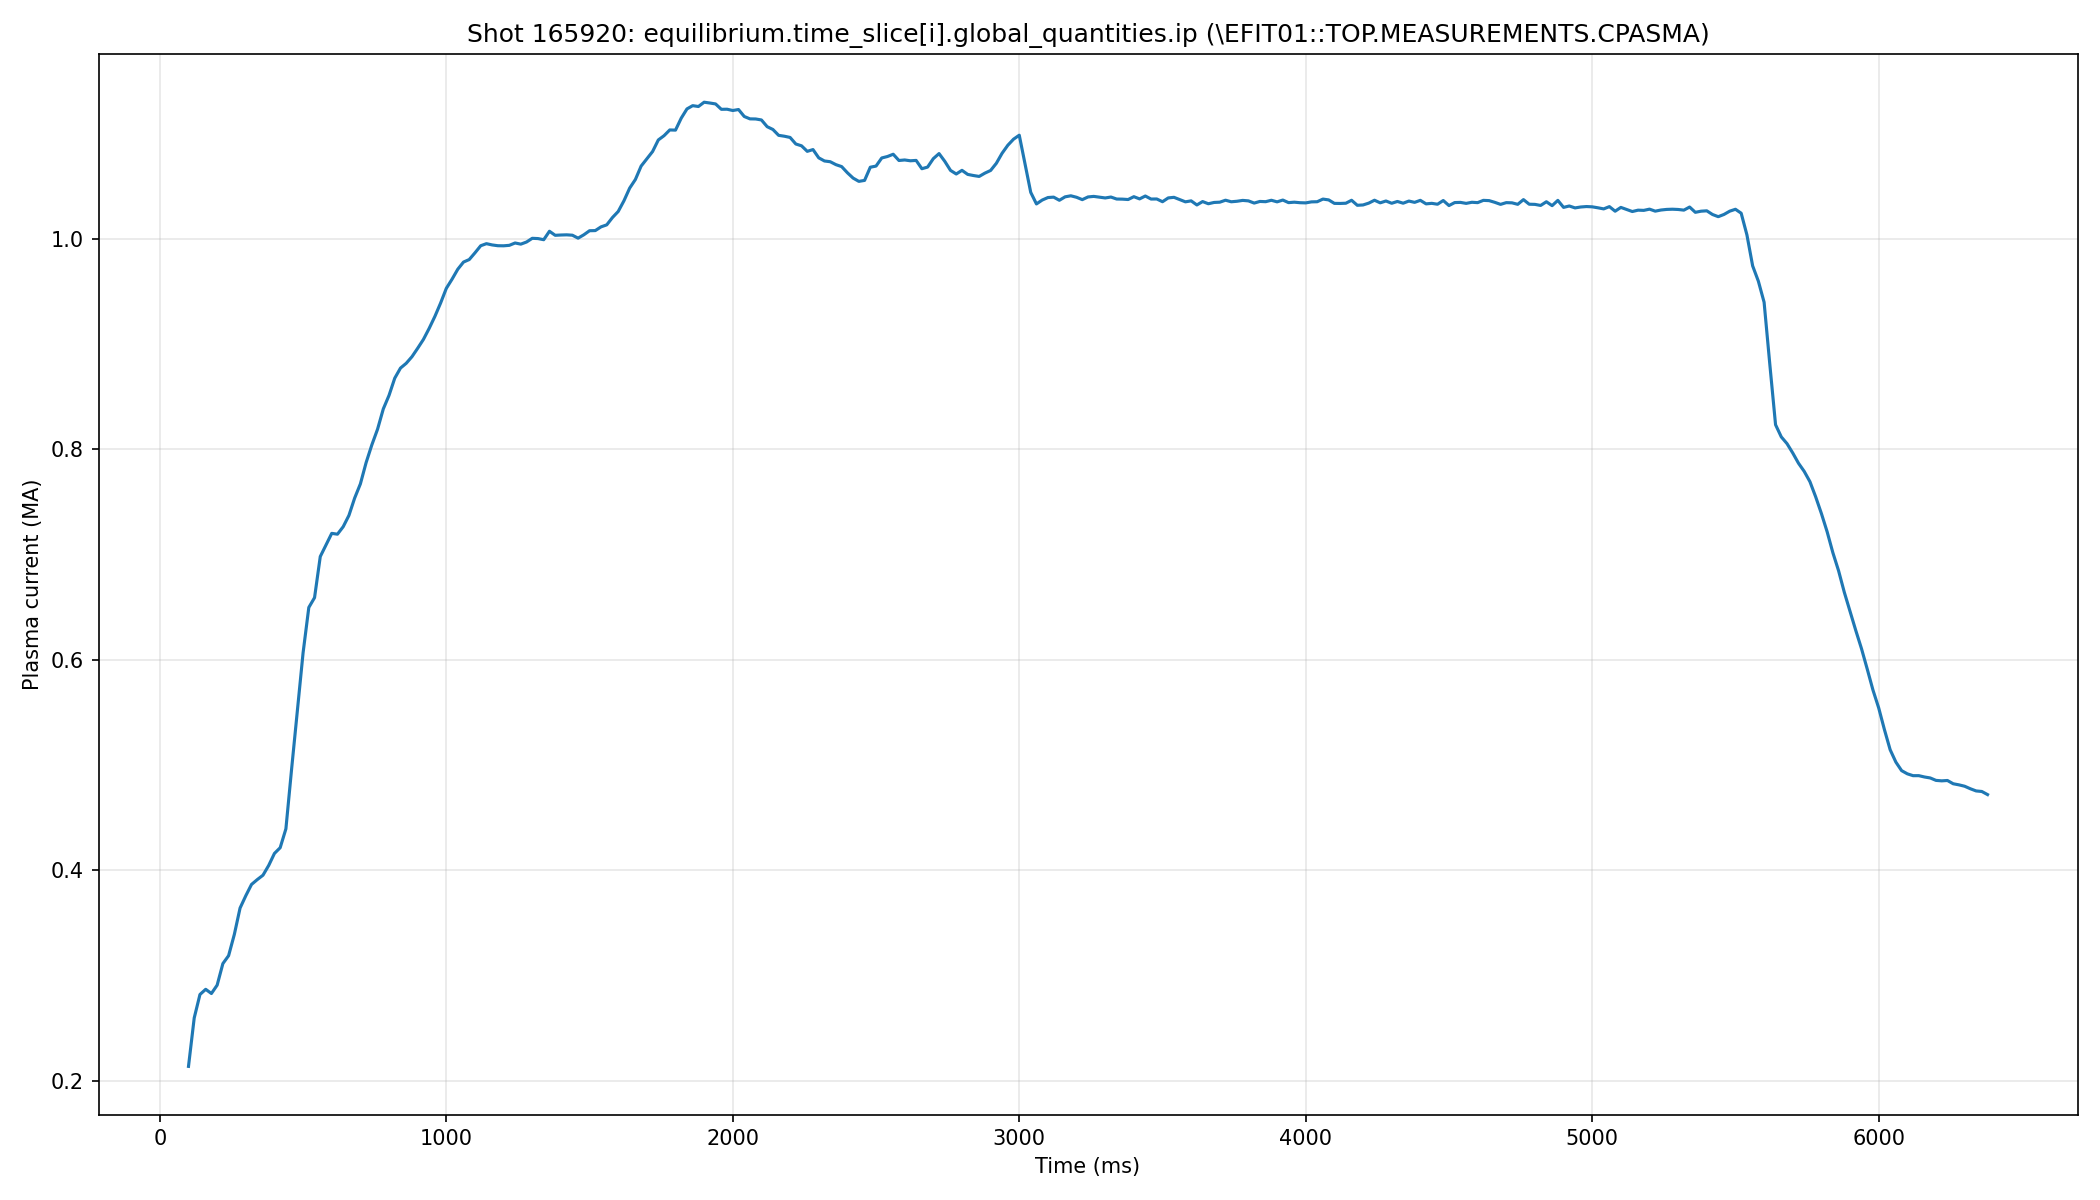

The raw time–current data is saved as `imas_ip_165920.csv` (columns: `time_ms, ip_A`), with the script `fetch_imas_ip_165920.py` in the working directory.

In [3]:
%%ask
For DIII-D shot 165920, fetch equilibrium.time_slice[i].global_quantities.ip
and plot it versus time